# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

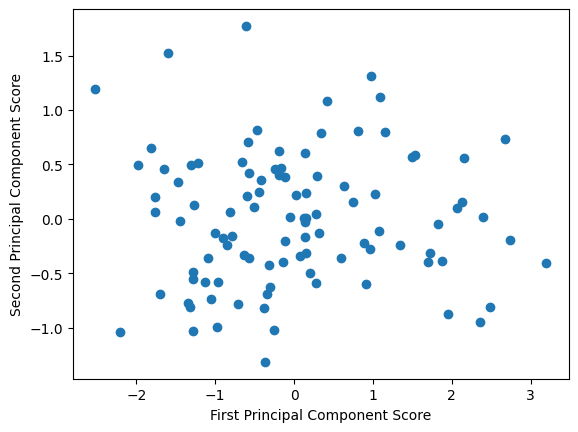

In [ ]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")



The three outliers in the upper left corner have low values for the first principal component and high values for the second principal component. Since the first principal component explains most of the variance (about 80%), a low value indicates that these points have relatively lower combined values across the variables. The second principal component captures additional variation, so high values indicate that these observations differ in another direction.

It is easier to interpret series_3 because it has more variability due to higher noise during its creation. This makes it more likely to produce extreme values that influence the PCA results. In contrast, series_1 and series_2 are highly correlated, since series_2 was generated directly from series_1 with only a small amount of noise. Because of this strong relationship, PCA cannot easily separate their individual effects, making it difficult to interpret their relative contributions.

The advantage of the PCA plot is that it reduces three variables into two dimensions, making it easier to visualize patterns and detect outliers. The disadvantage is that interpretation becomes less intuitive because each principal component is a combination of all variables. Overall, the graph does show interesting structure, particularly the presence of outliers and clustering.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("marketing_and_product_performance.csv")
df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


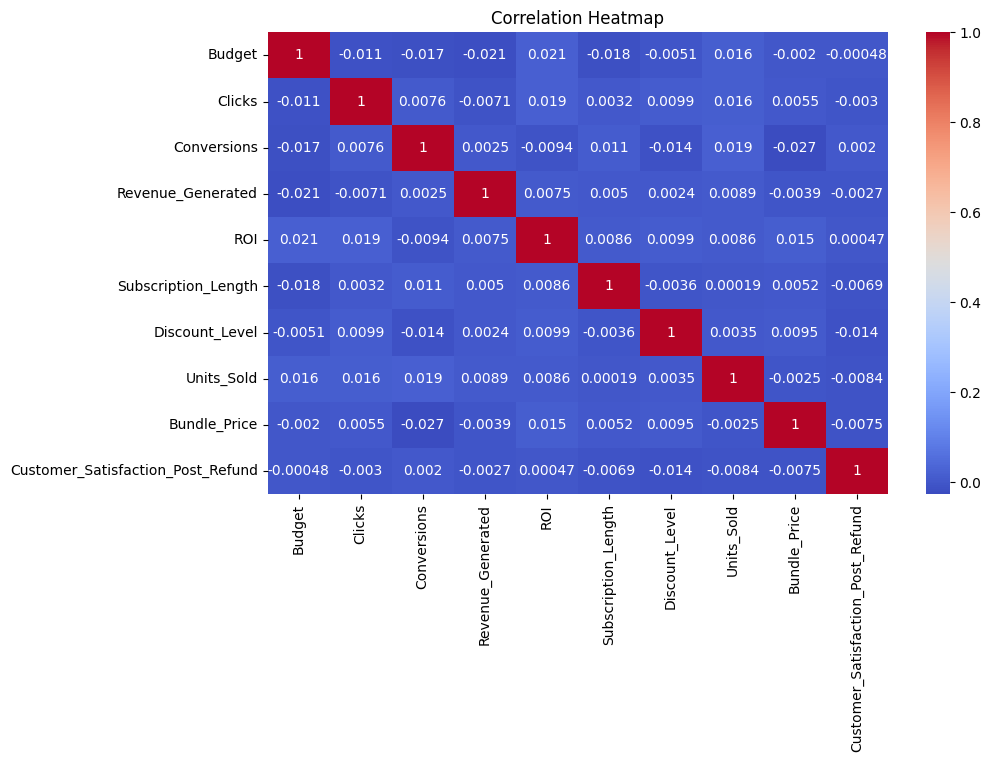

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between numerical variables in the dataset. Some features display moderate correlations, suggesting potential relationships useful for modeling. Most variables are not strongly correlated, which indicates that they provide unique information rather than being redundant.

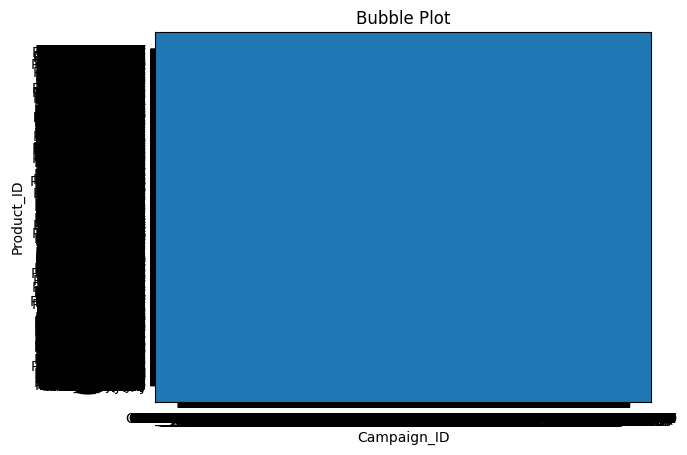

In [ ]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], 
            s=df.iloc[:,2]*10, alpha=0.5)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Bubble Plot")
plt.show()

The bubble plot allows visualization of three variables simultaneously. The x and y axes show two variables, while bubble size represents a third variable. This helps identify patterns, clusters, or relationships that are not visible in simpler plots.

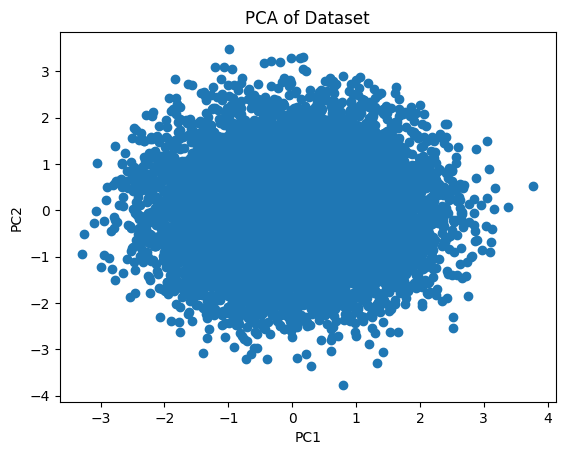

Explained variance: [0.10532823 0.10424239]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = df.select_dtypes(include=np.number).dropna()

X_scaled = StandardScaler().fit_transform(numeric_df)

pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)

plt.scatter(pc[:,0], pc[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Dataset")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)

PCA reduces the dataset into fewer dimensions while preserving most of the variability. The first principal component captures the largest portion of variance, while the second captures additional variation. This suggests that dimensionality reduction is possible and that the dataset structure can be simplified.

In [ ]:
from sklearn.linear_model import LinearRegression

numeric_df = df.select_dtypes(include=np.number).dropna()

X = numeric_df.iloc[:, :-1]
y = numeric_df.iloc[:, -1]

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)

Coefficients: [-4.93062891e-08 -2.10411040e-06  7.24813291e-06 -1.00827222e-07
  8.12193357e-04 -7.62133601e-04 -9.05550898e-04 -1.61820875e-04
 -6.32666976e-05]


Linear regression helps identify which features are useful for predicting the target variable. The coefficients show how each variable contributes to the prediction. Some variables have stronger influence than others, indicating their importance in modeling.

The dataset shows meaningful relationships between variables, although most correlations are moderate. PCA indicates that a large portion of variance can be captured using fewer dimensions, suggesting that dimensionality reduction is feasible. Some outliers are present, indicating variability in the data. Overall, the dataset appears usable for predictive modeling, though preprocessing and feature selection may improve performance.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

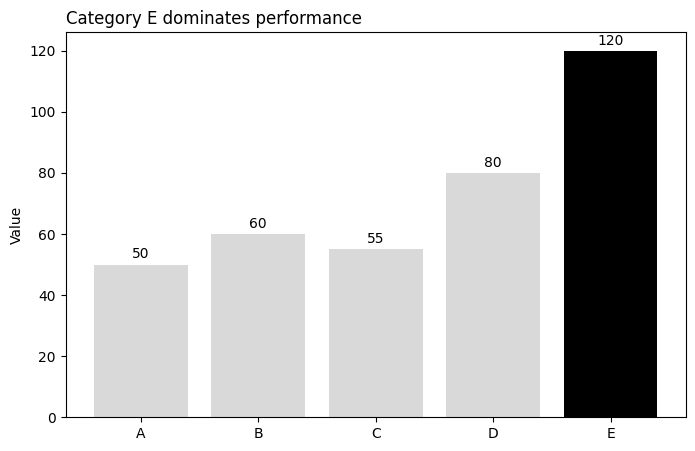

In [ ]:
import matplotlib.pyplot as plt

categories = ["A", "B", "C", "D", "E"]
values = [50, 60, 55, 80, 120]

colors = ["#d9d9d9"] * len(values)
colors[-1] = "#000000"

plt.figure(figsize=(8,5))
plt.bar(categories, values, color=colors)

plt.title("Category E dominates performance", loc="left")
plt.ylabel("Value")

for i, v in enumerate(values):
    plt.text(i, v + 2, str(v), ha="center")

plt.show()